In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.cm as cm
import numpy as np

In [4]:
df = pd.read_csv('/dataset_clustering_dnd.csv', sep=';')

In [5]:
df.head()

,Personagem,Classe_Relacionada,Poder_Magico_Distancia,Forca_Fisica_Engajamento
0,"Gandor, o Cinzento",Mago,9.5,1.5
1,"Thorgar, o Destruidor",Bárbaro,0.5,9.5
2,"Ionis, da Luz",Clérigo,7.0,6.5
3,"Alys, a Sombra",Ladino,2.0,5.5
4,"Eldrin, o Sábio",Feiticeiro,9.0,2.0


In [6]:
df.describe()

,Poder_Magico_Distancia,Forca_Fisica_Engajamento
count,10.000000,10.000000
mean,4.900000,5.950000
std,3.526093,2.929259
min,0.500000,1.500000
25%,1.625000,3.625000
50%,5.000000,6.250000
75%,8.125000,8.375000
max,9.500000,9.500000


In [7]:
# Aplicando o K-Means com 3 clusters
X = df[['Poder_Magico_Distancia', 'Forca_Fisica_Engajamento']]
kmeans=KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

In [8]:
# Posições dos centróides
kmeans.cluster_centers_

array([[1.8       , 7.7       ],
       [6.5       , 7.25      ],
       [9.        , 2.16666667]])

In [9]:
# Quais foram as classes criadas?
kmeans.labels_

array([2, 0, 1, 0, 2, 0, 1, 0, 2, 0], dtype=int32)

In [82]:
df['cluster_'] = kmeans.labels_

In [10]:
kmeans.inertia_

23.89166666666667

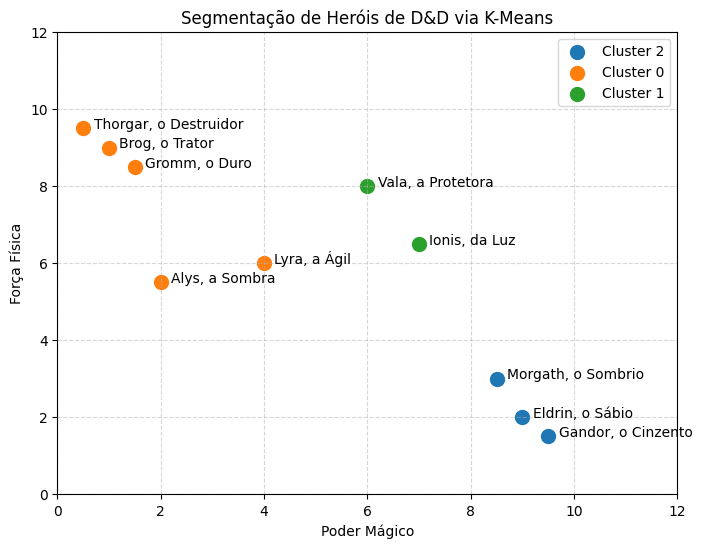

In [11]:
# Plotando o gráfico de dispersão (Scatter Plot)
plt.figure(figsize=(8, 6))
colors = {0: '#E63946', 1: '#457B9D', 2: '#A8DADC'}

for cluster_id in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['Poder_Magico_Distancia'], subset['Forca_Fisica_Engajamento'], label=f'Cluster {cluster_id}', s=100)
    for i, txt in enumerate(subset['Personagem']):
        plt.annotate(txt, (subset['Poder_Magico_Distancia'].iloc[i]+0.2, subset['Forca_Fisica_Engajamento'].iloc[i]))

plt.title('Segmentação de Heróis de D&D via K-Means')
plt.xlabel('Poder Mágico')
plt.ylabel('Força Física')
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [35]:
# Criamos um for que vai fazer uma série de testes com numeros diferentes da qtd de clusters,
# e com isso ele irá calcular o valor da inertia, e vamos adicionando esse valor no vetor "Sum_of_squared_distances"

X = df[['Poder_Magico_Distancia', 'Forca_Fisica_Engajamento']]

Sum_of_squared_distances = []
k_valores = range(1,7)
for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km = km.fit(X)
    Sum_of_squared_distances.append(km.inertia_)


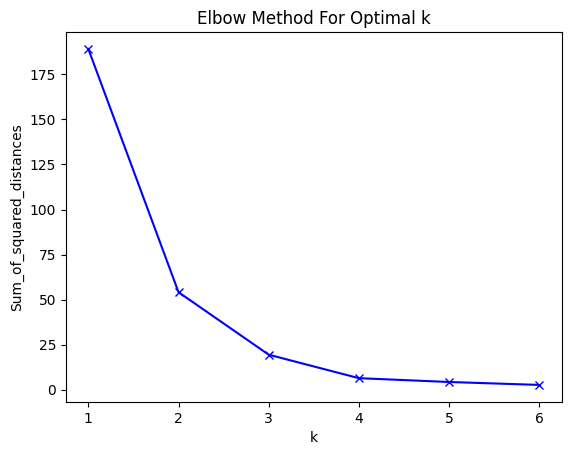

In [36]:
# Plotando o resultado
plt.plot(k_valores, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')

plt.show()

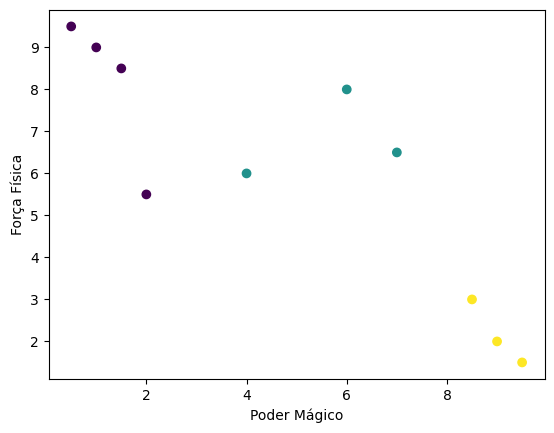

In [32]:
#calcutano a média com o numero encontrado no gráfico
kmeans_2=KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_2.fit(X)
df['cluster_'] = kmeans_2.labels_

#plotagem no gráficos
plt.xlabel('Poder Mágico')
plt.ylabel('Força Física')
plt.scatter(df['Poder_Magico_Distancia'], df['Forca_Fisica_Engajamento'], c=df['cluster_'])